# Porto Taxi — Popular Long Sub-Routes, Activity Zones & Anomalies

Interactive demo of the Spark pipeline's results, for **Colab Enterprise**.

It reads the small **result CSVs** produced by the mining jobs — top-100 routes
for each method at each length configuration, activity zones, anomalies — **not**
the raw 1.9 GB data, so it renders instantly.

Pipeline that produced these files (see `docs/DATAPROC.md`):
`clean_data → feature_engineering → spatial_encoding →
route_mining_{suffix_array, maximal, clustering, graph} → anomaly_analysis`.

**Methods**

| | method | how it finds routes |
|---|---|---|
| A | clustering | MinHash-LSH over directed bigram shingles → star clustering → the longest cell run its members share |
| B | maximal-frequent | contiguous n-gram support table → maximal among those clearing X%, X calibrated per length |
| C | transition graph | PageRank activity zones + dominant-flow heavy paths, validated against real trips |
| D | suffix array | generalised suffix array + LCP intervals — exact, without enumerating windows |

All four report the same unit: a contiguous sub-route with a distinct-trip support.

In [1]:
# 1. Setup. Idempotent: re-running is safe, and running it locally (where the
#    repo and the packages already exist) is a no-op.
import importlib.util, os, subprocess, sys

REPO = "https://github.com/noyaba1/Taxi.git"   # public

# Colab Enterprise starts on a bare VM: no repo, no packages. Cloning gives this
# notebook the committed `results/` bundle, and that is what takes GCS auth OFF
# the demo path entirely. The bucket fallback in cell 2 still exists, but a
# credential prompt in front of an audience is not a risk worth carrying for
# files that amount to a few MB of CSV.
FOUND = next((p for p in ("results/routes", "../results/routes")
              if os.path.isdir(p)), None)
if FOUND is None:
    subprocess.run(["git", "clone", "--depth", "1", REPO, "taxi_repo"], check=False)
    if os.path.isdir("taxi_repo/results/routes"):
        os.chdir("taxi_repo")
        FOUND = "results/routes"

for spec, mod in [("folium==0.16.0", "folium"), ("h3==3.7.7", "h3"),
                  ("matplotlib", "matplotlib"), ("gcsfs", "gcsfs")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", spec],
                       check=False)

import pandas as pd, folium, h3
print(f"pandas {pd.__version__} | folium {folium.__version__} | h3 {h3.__version__}")
print(f"cwd: {os.getcwd()}")
print(f"results/ bundle: {FOUND or 'NOT FOUND -- cell 2 falls back to gs://'}")

pandas 2.2.2 | folium 0.16.0 | h3 3.7.7
cwd: /Users/ofekhazum/Desktop/other/Taxi/notebooks
results/ bundle: ../results/routes


In [2]:
# 2. Where the result CSVs live.
#    Order matters, and it has bitten twice.
#      - `results/` FIRST: it is the committed bundle, the one the report and the
#        deck quote, and the only one that survives a fresh clone. It was absent
#        from this list, so a clean Colab runtime fell straight through to gs://
#        and needed bucket credentials to show anything.
#      - `outputs/` LAST: it is gitignored and, on a laptop, usually holds
#        SAMPLE-scale files. Preferring it meant SCALE='full' silently loaded
#        nothing and printed an all-zero coverage table that looked like a
#        finding rather than a misconfiguration.
import os

BUCKET = 'gs://taxi-project-noyabayazi'   # fallback only; needs credentials
PREFIX = 'taxi'                           # the folder INSIDE it. NOT 'porto':
                                          # the submit script defaults to porto,
                                          # this project's runs have always used
                                          # taxi, and the mismatch reads nothing.
SCALE  = 'full'                           # 'full' | 'mid' | 'sample'

CANDIDATES = ('results/routes', '../results/routes',
              'cloud_outputs/routes', '../cloud_outputs/routes',
              'outputs/routes', '../outputs/routes')
LOCAL = next((d for d in CANDIDATES
              if os.path.isdir(d) and any(f.endswith(f'_{SCALE}.csv')
                                          for f in os.listdir(d))), None)
BASE = LOCAL if LOCAL else f'{BUCKET}/{PREFIX}/outputs/routes'
print(f'reading from: {BASE}  (scale={SCALE})')

def load(name):
    try:
        return pd.read_csv(f'{BASE}/{name}_{SCALE}.csv')
    except Exception as e:
        print('skip', name, '->', type(e).__name__)
        return pd.DataFrame()

M = {'A': load('clustering_top100'),
     'B': load('maximal_frequent_top100'),
     'C': load('graph_heavy_paths_top100'),
     'D': load('suffix_array_top100')}
Z  = load('activity_zones')
AN = load('anomalies_top50')
print({k: len(v) for k, v in M.items()}, '| zones:', len(Z), '| anomalies:', len(AN))
print('\nB is empty at full scale BY DESIGN: maximal-frequent shares an O(n^2)'
      '\nwindow table that OOMs at 200k, and D reproduces its output exactly.')
if all(len(v) == 0 for v in M.values()):
    print('\n!! Nothing loaded. Check BUCKET/PREFIX/SCALE above -- an empty '
          'coverage table is a configuration error, not a result.')

reading from: ../results/routes  (scale=full)
skip maximal_frequent_top100 -> FileNotFoundError
{'A': 400, 'B': 0, 'C': 344, 'D': 500} | zones: 50 | anomalies: 50

B is empty at full scale BY DESIGN: maximal-frequent shares an O(n^2)
window table that OOMs at 200k, and D reproduces its output exactly.


In [3]:
# 3. Coverage: how many routes each method found at each length configuration.
#    An empty cell at >=20/40 km is a real finding, not a bug: it means no
#    corridor of that length is driven by enough distinct trips at this scale.
LENGTHS = [1, 3, 5, 10, 20, 40]
cov = pd.DataFrame(
    {m: {L: int((df['min_len_km'] == L).sum()) if len(df) else 0 for L in LENGTHS}
     for m, df in M.items()})
cov.index.name = 'min_len_km'
cov

,A,B,C,D
min_len_km,,,,
1,100,0,100,100
3,100,0,100,100
5,100,0,100,100
10,99,0,44,100
20,1,0,0,100
40,0,0,0,0


In [4]:
# 4. The map: every method x every length configuration as its own layer.
#    Use the layer control (top right) to switch between the six configurations.
DELIM = '>'
COLOURS = {'A': '#2e8b3d', 'B': '#1f5fbf', 'C': '#d1341c', 'D': '#7b2fbf'}
ROUTE_COL = {'A': 'subroute', 'B': 'subroute', 'C': 'route', 'D': 'subroute'}
LABEL = {'A': 'A clustering', 'B': 'B maximal-frequent',
         'C': 'C transition-graph', 'D': 'D suffix-array'}
SHOW_L = 3          # the band where every method has results

def polyline(cells):
    return [list(h3.h3_to_geo(c)) for c in str(cells).split(DELIM) if c]

m = folium.Map(location=(41.157, -8.629), zoom_start=12, tiles='cartodbpositron')

for key, df in M.items():
    if not len(df):
        continue
    for L in LENGTHS:
        sub = df[df.min_len_km == L].head(25)
        if not len(sub):
            continue
        fg = folium.FeatureGroup(name=f'{LABEL[key]} (>={L} km)', show=(L == SHOW_L))
        for _, r in sub.iterrows():
            pts = polyline(r[ROUTE_COL[key]])
            if len(pts) >= 2:
                folium.PolyLine(
                    pts, color=COLOURS[key], weight=3, opacity=0.7,
                    tooltip=f"{LABEL[key]} >={L}km | support={r['support']} "
                            f"| {r['length_km']:.2f} km").add_to(fg)
        fg.add_to(m)

if len(Z):
    zfg = folium.FeatureGroup(name='Activity zones (PageRank)', show=True)
    for _, z in Z.iterrows():
        folium.CircleMarker((z.lat, z.lon), radius=max(3, 14 - int(z['rank']) // 4),
                            color='#e8850c', fill=True, fill_opacity=0.5,
                            tooltip=f"zone #{z['rank']} pr={z['pagerank']:.5f}").add_to(zfg)
    zfg.add_to(m)

if len(AN):
    afg = folium.FeatureGroup(name='Anomalous routes', show=False)
    for _, a in AN.iterrows():
        folium.CircleMarker((a.start_lat, a.start_lon), radius=5, color='#555555',
                            fill=True, fill_opacity=0.7,
                            tooltip=f"score={a.anomaly_score} dist={a.dist_km}km").add_to(afg)
    afg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

In [5]:
# 5. The deliverable: top-100 popular long sub-routes for one config.
#    Method D (suffix array) is the default because it is the one that
#    carries the deliverable at full scale -- B is sample-scale only, so
#    hardcoding B here fails on a full-scale run.
METHOD = next((k for k in ('D', 'B', 'A', 'C') if len(M[k])), None)
L = 3   # one of 1, 3, 5, 10, 20, 40

if METHOD is None:
    print('no method produced routes; run the mining stages first')
else:
    df = M[METHOD]
    cols = [c for c in ['rank', 'support', 'support_taxis', 'length_km',
                        'n_cells', 'min_sup', 'x_pct'] if c in df.columns]
    print(f'Method {METHOD}, corridors of at least {L} km')
    display(df[df.min_len_km == L][cols].head(100))

Method D, corridors of at least 3 km


,rank,support,support_taxis,length_km,n_cells,min_sup,x_pct
100,1,8948,425,4.352,13,5000,0.30969
101,2,8725,285,5.101,15,5000,0.30969
102,3,8086,424,5.037,15,5000,0.30969
103,4,8045,434,5.134,15,5000,0.30969
104,5,7782,416,3.273,10,5000,0.30969
...,...,...,...,...,...,...,...
195,96,5435,403,3.278,10,5000,0.30969
196,97,5428,361,3.582,11,5000,0.30969
197,98,5414,420,3.265,10,5000,0.30969
198,99,5374,417,3.601,11,5000,0.30969


In [6]:
# 6. Do independent methods agree? Overlap of the cell sets they report at >=3 km.
#    Two methods with different failure modes converging on the same corridors is
#    the strongest evidence available that those corridors are real.
def cellsets(key, L=3):
    df = M[key]
    if not len(df):
        return []
    return [frozenset(str(r[ROUTE_COL[key]]).split(DELIM))
            for _, r in df[df.min_len_km == L].iterrows()]

def match_fraction(xs, ys, thr=0.5):
    if not xs or not ys:
        return float('nan')
    hit = sum(any(len(x & y) / len(x | y) >= thr for y in ys) for x in xs)
    return hit / len(xs)

present = [k for k in M if len(M[k])]
S = {k: cellsets(k) for k in present}
pd.DataFrame({c: {r: (1.0 if r == c else match_fraction(S[r], S[c])) for r in present}
              for c in present}).round(2)

,A,C,D
A,1.00,0.54,0.98
C,0.47,1.00,0.73
D,0.86,0.44,1.00


## 7. Strong scaling — does adding machines make it faster?

The only question here that cannot be answered on a laptop. The same 1.71M-trip
workload was run on clusters of 2, 5, 10 and 16 workers; every stage of every run
appended its wall time to `timings.jsonl` tagged with the cluster that produced
it, so the curve below is recovered from runs already paid for rather than
re-measured.


timings: ../results/statistics/timings.jsonl
dropped partial run 20260804T060821Z-w5 (7/11 stages)
dropped partial run 20260804T084923Z-w5 (5/11 stages)


,cluster_workers,minutes,speedup,efficiency,serial_pct
1,2,68.100000,1.00x,1.00,nan
0,5,65.800000,1.03x,0.41,94.400000
2,10,53.200000,1.28x,0.26,72.700000
3,16,50.300000,1.35x,0.17,70.100000


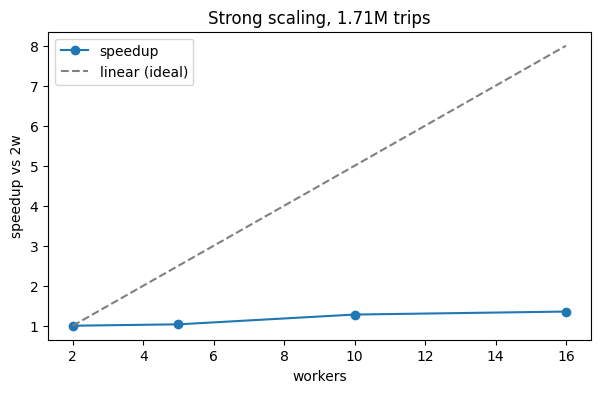

In [7]:
# 7. Speedup, parallel efficiency, and the Amdahl ceiling.
#    Reads timings.jsonl -- one row per stage per run, tagged with
#    cluster_workers and run_id by cli._cluster_tags.
#    `results/` first for the same reason as cell 2: it is the committed copy,
#    and the cluster-tagged rows exist ONLY in the cloud runs, so a fresh clone
#    that looked at ./outputs found a local file with no cluster tags at all and
#    reported "no cluster-tagged rows" as though the sweep had never happened.
import json, os, pandas as pd

TIMINGS = next((p for p in ('results/statistics/timings.jsonl',
                            '../results/statistics/timings.jsonl',
                            'cloud_outputs/statistics/timings.jsonl',
                            '../cloud_outputs/statistics/timings.jsonl',
                            'outputs/statistics/timings.jsonl',
                            '../outputs/statistics/timings.jsonl')
                if os.path.exists(p)), None)
print('timings:', TIMINGS)

rows = [json.loads(l) for l in open(TIMINGS) if l.strip()] if TIMINGS else []
t = pd.DataFrame([r for r in rows
                  if r.get('scale') == SCALE and 'cluster_workers' in r])

if t.empty:
    print('No cluster-tagged rows at scale', SCALE,
          '-- run the sweep first (WORKERS=2 5 10 16).')
else:
    # One run may appear twice if a cluster was recreated; group by run_id so a
    # partial, aborted run cannot be averaged into a complete one.
    per_run = (t.groupby(['run_id', 'cluster_workers'])
                 .agg(wall_s=('wall_s', 'sum'), stages=('stage', 'nunique'))
                 .reset_index())
    # An aborted run has far fewer stages than the best run; drop it rather than
    # let its short wall time masquerade as a fast cluster. Measured: one such
    # run reported 3.01x speedup at efficiency 1.20 -- superlinear, from having
    # done half the work. Same rule as src/experiment_cluster_scaling.py.
    full = per_run['stages'].max()
    dropped = per_run[per_run.stages < full]
    per_run = per_run[per_run.stages == full].sort_values('cluster_workers')
    for _, d in dropped.iterrows():
        print(f'dropped partial run {d.run_id} ({d.stages}/{full} stages)')

    base = per_run.iloc[0]
    per_run['speedup'] = base.wall_s / per_run.wall_s
    per_run['n'] = per_run.cluster_workers / base.cluster_workers
    per_run['efficiency'] = per_run.speedup / per_run.n
    # Karp-Flatt: p = (1/S - 1/n) / (1 - 1/n)
    per_run['serial_pct'] = [
        None if n <= 1 else round(100 * ((1/s - 1/n) / (1 - 1/n)), 1)
        for s, n in zip(per_run.speedup, per_run.n)]
    per_run['minutes'] = (per_run.wall_s / 60).round(1)
    display(per_run[['cluster_workers', 'minutes', 'speedup',
                     'efficiency', 'serial_pct']]
            .style.format({'speedup': '{:.2f}x', 'efficiency': '{:.2f}'}))

    ax = per_run.plot(x='cluster_workers', y='speedup', marker='o',
                      figsize=(7, 4), legend=False)
    ax.plot(per_run.cluster_workers, per_run.n, '--', color='grey',
            label='linear (ideal)')
    ax.set_xlabel('workers'); ax.set_ylabel(f'speedup vs {int(base.cluster_workers)}w')
    ax.set_title('Strong scaling, 1.71M trips'); ax.legend()